# 1. Chargement et exploration

In [1]:
### Import des differents packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
lv=pd.read_csv("livraisons_translog_1M.csv",sep=",")
print("Les dimensions du dataset sont les suivantes:",lv.shape)
print(lv.info())

Les dimensions du dataset sont les suivantes: (1000000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   ID_livraison       1000000 non-null  object 
 1   Date_envoi         1000000 non-null  object 
 2   Ville_depart       1000000 non-null  object 
 3   Ville_arrivee      1000000 non-null  object 
 4   Transporteur       1000000 non-null  object 
 5   Chauffeur_ID       1000000 non-null  object 
 6   Type_colis         1000000 non-null  object 
 7   Poids_kg           1000000 non-null  float64
 8   Distance_km        1000000 non-null  int64  
 9   Cout_transport     1000000 non-null  float64
 10  Delai_livraison    921374 non-null   float64
 11  Statut             1000000 non-null  object 
 12  Note_satisfaction  815827 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 99.2+ MB
None


In [3]:
lv.head(5)

,ID_livraison,Date_envoi,Ville_depart,Ville_arrivee,Transporteur,Chauffeur_ID,Type_colis,Poids_kg,Distance_km,Cout_transport,Delai_livraison,Statut,Note_satisfaction
0,LIV-00000001,2020-01-01,Lille,Marseille,TransLog Express,CHF-015,Standard,7.48,220,17.19,8.0,Retard,1.0
1,LIV-00000002,2020-01-01,Rennes,Bordeaux,RapidColis,CHF-049,Standard,0.77,934,1.95,3.0,Livré,5.0
2,LIV-00000003,2020-01-01,Bordeaux,Dijon,EcoFret,CHF-034,Fragile,4.84,998,23.03,4.0,Livré,3.0
3,LIV-00000004,2020-01-01,Paris,Rouen,EcoFret,CHF-018,Standard,1.73,393,3.80,12.0,Retard,3.0
4,LIV-00000005,2020-01-01,Marseille,Lyon,UltraSpeed,CHF-040,Standard,1.65,1184,3.99,6.0,En transit,NaN


In [4]:
###  pourcentage de valeurs manquantes dans chaque colonne

pourcentage_valeurs_manquantes = (lv.isna().sum() / len(lv)) * 100
print("Le pourcentage de valeur manquantes dans chaque colonne",pourcentage_valeurs_manquantes)

Le pourcentage de valeur manquantes dans chaque colonne ID_livraison          0.0000
Date_envoi            0.0000
Ville_depart          0.0000
Ville_arrivee         0.0000
Transporteur          0.0000
Chauffeur_ID          0.0000
Type_colis            0.0000
Poids_kg              0.0000
Distance_km           0.0000
Cout_transport        0.0000
Delai_livraison       7.8626
Statut                0.0000
Note_satisfaction    18.4173
dtype: float64


# Nettoyage des donnés & Traitement des valeurs manquantes


In [5]:
#### Transformatiion de la date en Datetime
lv['New_Date_envoi']=pd.to_datetime(lv["Date_envoi"])

### Verification du changement en datetime
lv["New_Date_envoi"].info()

### Suppression de l'ancienne version de Date_envoie
lv.drop("Date_envoi",axis=1,inplace=True)  ### Attention !:A executer une seule fois


<class 'pandas.core.series.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: New_Date_envoi
Non-Null Count    Dtype         
--------------    -----         
1000000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 7.6 MB


In [6]:
print(lv.shape) ### Verification de l'etat de notre dimension
lv["New_Date_envoi"].info()
lv.head()

(1000000, 13)
<class 'pandas.core.series.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: New_Date_envoi
Non-Null Count    Dtype         
--------------    -----         
1000000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 7.6 MB


,ID_livraison,Ville_depart,Ville_arrivee,Transporteur,Chauffeur_ID,Type_colis,Poids_kg,Distance_km,Cout_transport,Delai_livraison,Statut,Note_satisfaction,New_Date_envoi
0,LIV-00000001,Lille,Marseille,TransLog Express,CHF-015,Standard,7.48,220,17.19,8.0,Retard,1.0,2020-01-01
1,LIV-00000002,Rennes,Bordeaux,RapidColis,CHF-049,Standard,0.77,934,1.95,3.0,Livré,5.0,2020-01-01
2,LIV-00000003,Bordeaux,Dijon,EcoFret,CHF-034,Fragile,4.84,998,23.03,4.0,Livré,3.0,2020-01-01
3,LIV-00000004,Paris,Rouen,EcoFret,CHF-018,Standard,1.73,393,3.80,12.0,Retard,3.0,2020-01-01
4,LIV-00000005,Marseille,Lyon,UltraSpeed,CHF-040,Standard,1.65,1184,3.99,6.0,En transit,NaN,2020-01-01


In [7]:
### Traitement des valeurs manquantes dans les colonnes Delai de livraison et note satisfaction
### Pour la colonne delai de livraison
### On calcule la moyenne et la mediane afin de prendre la meilleur decision des deux
print(lv["Delai_livraison"].aggregate(func=["mean","median"]))

### On remplace des valeurs manquantes par la median
lv["Delai_livraison"].fillna(value=lv["Delai_livraison"].median(),inplace=True)


mean      4.056589
median    3.000000
Name: Delai_livraison, dtype: float64


/tmp/ipykernel_582/1811196326.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lv["Delai_livraison"].fillna(value=lv["Delai_livraison"].median(),inplace=True)


In [8]:
### Remplacement des valeurs manquantes dans la colonne note satisfaction
### On verifie voir quelles sont les notes de satisfaction qui apparaise dans le Dataset
lv["Note_satisfaction"].unique()

### On cherche la note qui apparait le plus
lv["Note_satisfaction"].mode()

### On remplace les valeurs manquantes de la colonne par la note_satisfaction qui apparait le plus
lv["Note_satisfaction"].fillna(value=lv["Note_satisfaction"].mode()[0],inplace=True)


/tmp/ipykernel_582/3795194396.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lv["Note_satisfaction"].fillna(value=lv["Note_satisfaction"].mode()[0],inplace=True)


In [9]:
### Verification: Pour voir s'il n'y a plus de valeurs manquantes dans le dataset
lv.isna().sum()

,0
ID_livraison,0
Ville_depart,0
Ville_arrivee,0
Transporteur,0
Chauffeur_ID,0
Type_colis,0
Poids_kg,0
Distance_km,0
Cout_transport,0
Delai_livraison,0


In [10]:
### Resumé statistique des valeurs numerique du dataset
lv.describe()

,Poids_kg,Distance_km,Cout_transport,Delai_livraison,Note_satisfaction,New_Date_envoi
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000
mean,14.742811,664.538783,36.910759,3.973514,4.069073,2022-07-02 10:01:22.367999744
min,0.300000,30.000000,1.030000,1.000000,1.000000,2020-01-01 00:00:00
25%,4.260000,347.000000,13.460000,2.000000,4.000000,2021-04-01 00:00:00
50%,8.100000,664.000000,24.990000,3.000000,5.000000,2022-07-03 00:00:00
75%,14.110000,982.000000,40.090000,4.000000,5.000000,2023-10-02 00:00:00
max,80.000000,1299.000000,172.730000,14.000000,5.000000,2024-12-31 00:00:00
std,18.044872,366.541825,35.620787,3.093681,1.239082,NaN


In [11]:
### Mise en place d'une boite a moustache pour la detection d'outlier

# Enrechissement

In [12]:
### Ajout du mois d'envoie dans le dataset en format "2022-02"
lv["Mois_envoie"]=lv["New_Date_envoi"].dt.strftime("%Y-%m")

### Ajout du cout/km dans le dataset
lv["Cout_par_Km"]= np.array(lv["Cout_transport"]/lv["Distance_km"])

### Ajout de Est_en_retard — booléen True si le statut est “Retard” ou “Perdu”
lv.loc[lv["Statut"]=="Retard","Est_en_retard_ou_Perdu"]=True
lv.loc[lv["Statut"]=="Perdu","Est_en_retard_ou_Perdu"]=True
lv.loc[lv["Statut"]=="Livré","Est_en_retard_ou_Perdu"]=False
lv.loc[lv["Statut"]=="En transit","Est_en_retard_ou_Perdu"]=False


#### Mise en place des catégories de poids
lv["Categorie_poids"]=pd.cut(x=lv["Poids_kg"], bins=[0,5,20, lv["Poids_kg"].max()], labels=["Leger","Moyen","Lourd"], right=False , include_lowest=True)

lv.head()


,ID_livraison,Ville_depart,Ville_arrivee,Transporteur,Chauffeur_ID,Type_colis,Poids_kg,Distance_km,Cout_transport,Delai_livraison,Statut,Note_satisfaction,New_Date_envoi,Mois_envoie,Cout_par_Km,Est_en_retard_ou_Perdu,Categorie_poids
0,LIV-00000001,Lille,Marseille,TransLog Express,CHF-015,Standard,7.48,220,17.19,8.0,Retard,1.0,2020-01-01,2020-01,0.078136,True,Moyen
1,LIV-00000002,Rennes,Bordeaux,RapidColis,CHF-049,Standard,0.77,934,1.95,3.0,Livré,5.0,2020-01-01,2020-01,0.002088,False,Leger
2,LIV-00000003,Bordeaux,Dijon,EcoFret,CHF-034,Fragile,4.84,998,23.03,4.0,Livré,3.0,2020-01-01,2020-01,0.023076,False,Leger
3,LIV-00000004,Paris,Rouen,EcoFret,CHF-018,Standard,1.73,393,3.80,12.0,Retard,3.0,2020-01-01,2020-01,0.009669,True,Leger
4,LIV-00000005,Marseille,Lyon,UltraSpeed,CHF-040,Standard,1.65,1184,3.99,6.0,En transit,5.0,2020-01-01,2020-01,0.003370,False,Leger


# Analyse par aggregation

### 1. Le chiffre d’affaires mensuel total et son évolution en m % d'un mois sur l'autre


In [13]:
### Calculons le chiffre d'affaire mensuel total

# Définir la colonne de date comme index pour pouvoir utiliser resample
lv_indexed = lv.set_index("New_Date_envoi")
somme_cout_transport = lv_indexed["Cout_transport"].resample("M").sum()


### Le % de variation d'un mois par rapport à l'autre
variation_mensuelle = somme_cout_transport.pct_change() * 100

### Mettons le resultat obtenue sous forme de DF

resultats_mensuels=pd.DataFrame({"somme_cout_transport":somme_cout_transport,"variation_mensuelle en %":variation_mensuelle})

#### Affichage du resultat
resultats_mensuels

/tmp/ipykernel_582/3635003803.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  somme_cout_transport = lv_indexed["Cout_transport"].resample("M").sum()


,somme_cout_transport,variation_mensuelle en %
New_Date_envoi,,
2020-01-31,630599.58,NaN
2020-02-29,582087.48,-7.693012
2020-03-31,615654.98,5.766745
2020-04-30,605370.67,-1.670466
2020-05-31,633221.51,4.600626
2020-06-30,606562.93,-4.209993
2020-07-31,620850.27,2.355459
2020-08-31,639920.08,3.071563
2020-09-30,606647.99,-5.199413


### 2. Par transporteur : le nombre de livraisons, le taux de retard (%), le délai moyen de livraison et la note de satisfaction moyenne

In [14]:
### Le nombre de livraison par transporteur

nbre_livrai_par_transporteur=lv.groupby('Transporteur')["ID_livraison"].count()

### Le taux de retard par transporteur
# On filtre sur le statut retard
## On calcule le nbre de retard par transporteur
nbre_retard_par_transporteur_series = lv[lv["Statut"] == "Retard"].groupby("Transporteur").size()

### # Calculer le taux de retard pour chaque transporteur
# Reindex permet de s'assurer que tous les transporteurs sont présents,

taux_retard_par_transporteur = (nbre_retard_par_transporteur_series.reindex(nbre_livrai_par_transporteur.index, fill_value=0) / nbre_livrai_par_transporteur * 100).round(2)

### Calcule du delai moyen de livraison

delai_moyen_livraison=round(lv.groupby("Transporteur")["Delai_livraison"].mean(),3)

### La note de satisfaction moyenne par transporteur
note_satisfaction_moyenne=round(lv.groupby("Transporteur")["Note_satisfaction"].mean(),3)

### Combiner tous les resultats dans un seul DataFrame

analyse_par_transporteur = pd.DataFrame({
    'Nombre de livraisons': nbre_livrai_par_transporteur,
    'Taux de retard (%)': taux_retard_par_transporteur,
    'Délai moyen de livraison (jours)': delai_moyen_livraison,
    'Note de satisfaction moyenne': note_satisfaction_moyenne
})

### Affichage du resultat

display(analyse_par_transporteur)


,Nombre de livraisons,Taux de retard (%),Délai moyen de livraison (jours),Note de satisfaction moyenne
Transporteur,,,,
EcoFret,250456,16.94,3.972,4.073
RapidColis,250352,17.11,3.977,4.065
TransLog Express,250115,17.08,3.978,4.068
UltraSpeed,249077,17.00,3.968,4.070


### 3. Par type de colis : le coût moyen par km, le poids moyen et le nombre de colis perdus

In [15]:
### Par type de colis le cout moyen par km
cout_moyen_par_type_de_colis = round(lv.groupby("Type_colis")["Cout_par_Km"].mean().sort_values(ascending=False),3)
cout_moyen_par_type_de_colis

### Le poids moyen par type de colis
poids_moyen_par_type_de_colis=round(lv.groupby("Type_colis")["Poids_kg"].mean().sort_values(ascending=False),2)
poids_moyen_par_type_de_colis

### Le nombre de colis perdu pour chaque type
### A ne pas oublier !!! "La colonne Est_en_retard" contient True pour les colis perdu ou en retard et False pour les colis livré ou en transit
##### On filtre d'abord sur le statut perdu qui nous interesse le plus avant de grouper

perdu_par_type=lv[lv["Statut"]=="Perdu"].groupby("Type_colis").size().sort_values(ascending=False)
perdu_par_type

### On va mettre tous ca dans un DF

analyse_par_type_colis=pd.DataFrame({"cout_Moyen":cout_moyen_par_type_de_colis,
                                     "Poids_Moyen":poids_moyen_par_type_de_colis,
                                     "Les_colis_perdu":perdu_par_type

})

#### Affichage du DataFrame
display(analyse_par_type_colis)


,cout_Moyen,Poids_Moyen,Les_colis_perdu
Type_colis,,,
Fragile,0.051,4.15,9971
Réfrigéré,0.209,10.50,5076
Standard,0.059,7.75,25309
Volumineux,0.248,45.01,10010


### 4. Le classement des 5 chauffeurs avec le plus faible taux de retard (parmi ceux ayant au moins 10 livraisons)

In [29]:
# 1. Calculer le nombre total de livraisons par chauffeur
livraisons_par_chauffeur = lv.groupby('Chauffeur_ID').size().reset_index(name='Nombre_livraisons')

# 2. Calculer le nombre de livraisons STRICTEMENT en retard (Statut == "Retard") par chauffeur
#    Nous filtrons directement sur le statut 'Retard' ici.
nombre_retards_purs_par_chauffeur = lv[lv['Statut'] == 'Retard'].groupby('Chauffeur_ID').size().reset_index(name='Nombre_retards_purs')

# 3. Fusionner les informations sur les livraisons totales et les retards purs
#    Utiliser un left merge pour conserver tous les chauffeurs et remplir NaN (pour les chauffeurs sans retards purs) avec 0
analyse_chauffeurs = pd.merge(
    livraisons_par_chauffeur,
    nombre_retards_purs_par_chauffeur,
    on='Chauffeur_ID',
    how='left'
).fillna(0) # Remplir 0 pour les chauffeurs sans retards purs

# 4. Calculer le taux de retard (uniquement 'Retard') en pourcentage
analyse_chauffeurs['Taux_retard_pct'] = (analyse_chauffeurs['Nombre_retards_purs'] / analyse_chauffeurs['Nombre_livraisons']) * 100

# 5. Filtrer les chauffeurs ayant au moins 10 livraisons au total
chauffeurs_qualifies = analyse_chauffeurs[analyse_chauffeurs['Nombre_livraisons'] >= 10]

# 6. Classer les 5 chauffeurs avec le plus faible taux de retard (uniquement 'Retard')
classement_chauffeurs = chauffeurs_qualifies.sort_values(by='Taux_retard_pct', ascending=True).head(5)

# Afficher le résultat
display('Les 5 chauffeurs avec le plus faible taux de retard:',classement_chauffeurs)

'Les 5 chauffeurs avec le plus faible taux de retard:'

,Chauffeur_ID,Nombre_livraisons,Nombre_retards_purs,Taux_retard_pct
28,CHF-029,20013,3322,16.599211
1,CHF-002,20000,3334,16.670000
27,CHF-028,19995,3335,16.679170
8,CHF-009,19875,3315,16.679245
16,CHF-017,20130,3358,16.681570


### 5. La correlation entre distance_km et cout_transport

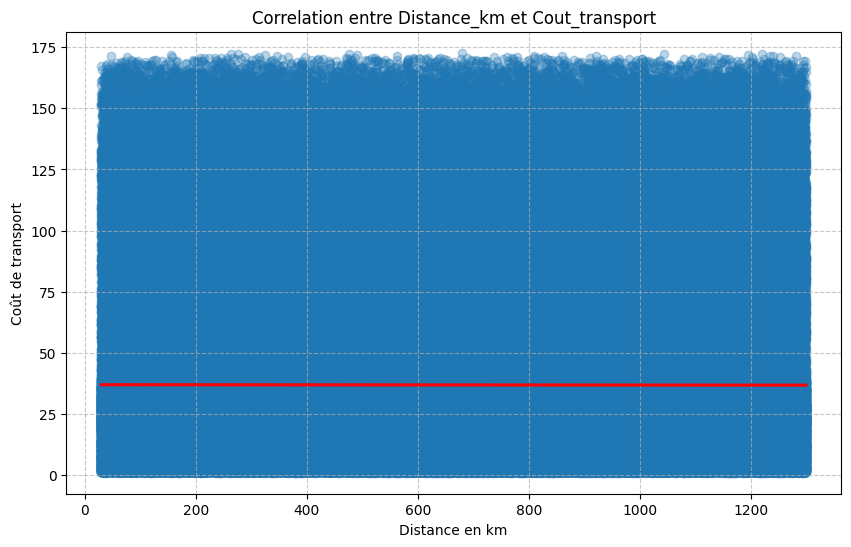

Pearson Correlation (r) between Distance_km and Cout_transport: -0.001
P-value: 0.1512


In [18]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Creer un scatter plot avec une regression linéaire Distance_km et Cout_transport
plt.figure(figsize=(10, 6))
sns.regplot(x='Distance_km', y='Cout_transport', data=lv, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Correlation entre Distance_km et Cout_transport')
plt.xlabel('Distance en km')
plt.ylabel('Coût de transport')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Recalculate and print the Pearson correlation coefficient for clarity
r, p = stats.pearsonr(lv['Distance_km'].dropna(), lv['Cout_transport'].dropna())
print(f"Pearson Correlation (r) between Distance_km and Cout_transport: {r:.3f}")
print(f"P-value: {p:.4f}")

#### Le coefficient de corrélation de Pearson entre Distance_km et Cout_transport est de -0.001, ce qui est extrêmement proche de zéro. La p-value de 0.1512 indique que cette corrélation n'est pas statistiquement significative.

En résumé : Il n'y a pratiquement aucune relation linéaire entre la distance parcourue et le coût de transport dans cet ensemble de données.

Cela paraît-il logique ? Intuitivement, on s'attendrait à ce que le coût augmente avec la distance. Cependant, pour ce dataset, il est possible que d'autres facteurs (comme le poids du colis, qui a montré une forte corrélation positive avec le coût) soient bien plus déterminants, ou que la relation ne soit pas linéaire du tout.

### 6.La corrélation entre Delai_livraison et Note_satisfaction

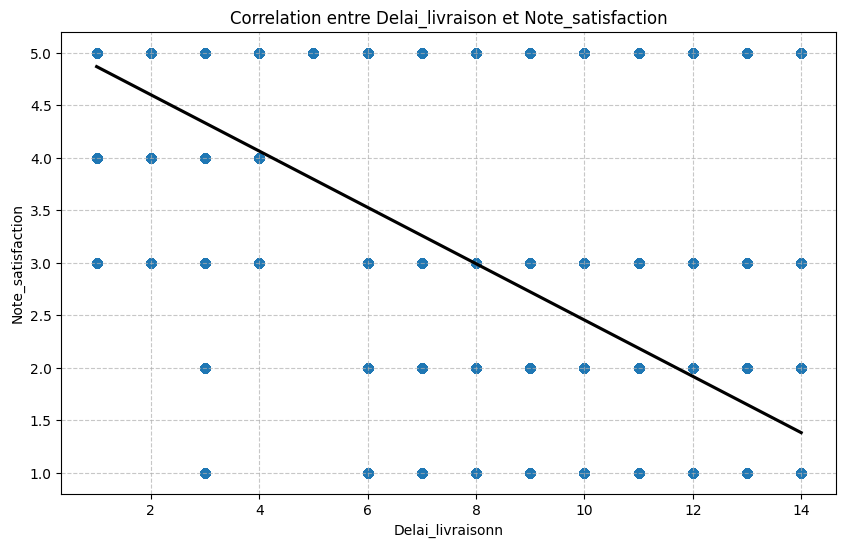

Pearson Correlation (r) between Delai_livraison and Note_satisfaction: -0.670
P-value: 0.0000


In [19]:
### Mise en place du scatter plot avec regression linéaire entre le Delai de livraison et la note de satisfaction
plt.figure(figsize=(10, 6))
sns.regplot(x='Delai_livraison', y='Note_satisfaction', data=lv, scatter_kws={'alpha':0.3}, line_kws={'color':'black'})
plt.title('Correlation entre Delai_livraison et Note_satisfaction')
plt.xlabel('Delai_livraisonn')
plt.ylabel('Note_satisfaction')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Calcule et affichage du coefficient de correlation Pearson

r, p = stats.pearsonr(lv['Delai_livraison'].dropna(), lv['Note_satisfaction'].dropna())
print(f"Pearson Correlation (r) between Delai_livraison and Note_satisfaction: {r:.3f}")
print(f"P-value: {p:.4f}")

### Que peut on conclure ?

##### Les calcules et la visualisation faite montre que le coefficient de correlation de Person est r = -0.670 ( ce qui est une correlation modérer négative ) et le faite que p-value tend vers 0 indique que cette correlation n'est absolument pas du au hasard et qu'elle est statistiquement très significative.
#### Cela signifie concrètement que plus le délai de livraison est long, plus la note de satisfaction tend à diminuer.

# Correlation entre tout les données numériques du Dataset


Matrice de corrélation:


,Poids_kg,Distance_km,Cout_transport,Delai_livraison,Note_satisfaction
Poids_kg,1.000000,-0.001455,0.876203,-0.000470,-0.000112
Distance_km,-0.001455,1.000000,-0.001435,0.001150,0.000862
Cout_transport,0.876203,-0.001435,1.000000,-0.000744,0.000815
Delai_livraison,-0.000470,0.001150,-0.000744,1.000000,-0.669546
Note_satisfaction,-0.000112,0.000862,0.000815,-0.669546,1.000000


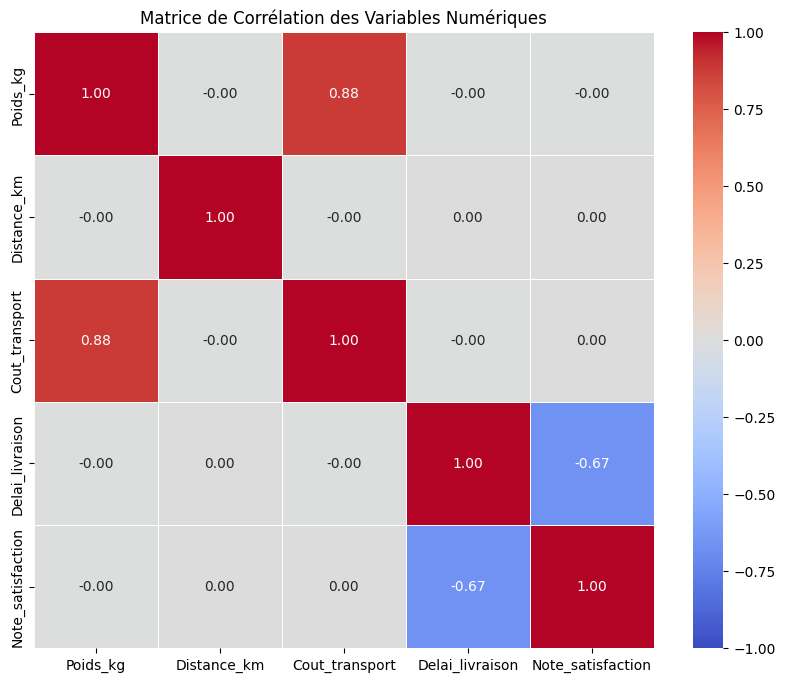

In [20]:
# Select numerical columns for correlation matrix
numerical_cols = ['Poids_kg', 'Distance_km', 'Cout_transport', 'Delai_livraison', 'Note_satisfaction']
correlation_matrix = lv[numerical_cols].corr()

# Display the correlation matrix
print("Matrice de corrélation:")
display(correlation_matrix)

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Matrice de Corrélation des Variables Numériques')
plt.show()


# 7. Les percentilles du cout de transport

In [21]:
# To calculate percentiles, use the .quantile() method on the Series.
# For example, to get the 25th, 50th (median), and 75th percentiles
quantil_lv=lv["Cout_transport"].quantile([0.25, 0.5, 0.75, 0.90])

print("Détail des Quantiles pour le 'Cout_transport' :")
print(f"- 25ème Percentile (Q1) : {quantil_lv[0.25]:.2f}")
print(f"- 50ème Percentile (Médiane/Q2) : {quantil_lv[0.50]:.2f}")
print(f"- 75ème Percentile (Q3) : {quantil_lv[0.75]:.2f}")
print(f"- 90ème Percentile : {quantil_lv[0.90]:.2f}")

print("\nInterprétation :")
print("  - 25% des livraisons coûtent moins de {0:.2f} unités.".format(quantil_lv[0.25]))
print("  - La moitié (50%) des livraisons coûtent moins de {0:.2f} unités.".format(quantil_lv[0.50]))
print("  - 75% des livraisons coûtent moins de {0:.2f} unités.".format(quantil_lv[0.75]))
print("  - Seuls 10% des livraisons les plus chères dépassent {0:.2f} unités.".format(quantil_lv[0.90]))

Détail des Quantiles pour le 'Cout_transport' :
- 25ème Percentile (Q1) : 13.46
- 50ème Percentile (Médiane/Q2) : 24.99
- 75ème Percentile (Q3) : 40.09
- 90ème Percentile : 98.91

Interprétation :
  - 25% des livraisons coûtent moins de 13.46 unités.
  - La moitié (50%) des livraisons coûtent moins de 24.99 unités.
  - 75% des livraisons coûtent moins de 40.09 unités.
  - Seuls 10% des livraisons les plus chères dépassent 98.91 unités.


# 8.Detection de Livraison a cout anormalement élévé ( Outlier )

In [23]:
### Utilisation de la methode IQR pour la détection d'outliers

# Récupération des quantiles calculés précédemment
Q1 = quantil_lv[0.25]
Q2 = quantil_lv[0.50] # Médiane
Q3 = quantil_lv[0.75]

# Calcul de l'IQR (InterQuartile Range)
IQR = Q3 - Q1

# Calcul des bornes supérieure et inférieure pour la détection d'outliers
borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR # La borne supérieure doit utiliser Q3, pas Q2

print(f"IQR : {IQR:.2f}")
print(f"Borne inférieure (Outliers) : {borne_inf:.2f}")
print(f"Borne supérieure (Outliers) : {borne_sup:.2f}")

# Identification des livraisons à coût anormalement élevé (outliers)
outliers_cout_transport = lv[(lv['Cout_transport'] < borne_inf) | (lv['Cout_transport'] > borne_sup)]

print(f"\nNombre de livraisons avec un coût anormalement élevé (outliers) : {len(outliers_cout_transport)}")
print("Voici les premières livraisons considérées comme outliers de coût :")
display(outliers_cout_transport.head())

IQR : 26.63
Borne inférieure (Outliers) : -26.49
Borne supérieure (Outliers) : 80.04

Nombre de livraisons avec un coût anormalement élevé (outliers) : 144719
Voici les premières livraisons considérées comme outliers de coût :


,ID_livraison,Ville_depart,Ville_arrivee,Transporteur,Chauffeur_ID,Type_colis,Poids_kg,Distance_km,Cout_transport,Delai_livraison,Statut,Note_satisfaction,New_Date_envoi,Mois_envoie,Cout_par_Km,Est_en_retard_ou_Perdu,Categorie_poids
10,LIV-00000011,Paris,Nice,TransLog Express,CHF-043,Volumineux,66.88,1063,110.95,3.0,Livré,5.0,2020-01-01,2020-01,0.104374,False,Lourd
19,LIV-00000020,Strasbourg,Nantes,TransLog Express,CHF-020,Réfrigéré,14.48,380,107.08,4.0,Livré,4.0,2020-01-01,2020-01,0.281789,False,Moyen
27,LIV-00000028,Paris,Lille,RapidColis,CHF-020,Réfrigéré,16.30,444,119.01,1.0,Livré,5.0,2020-01-01,2020-01,0.268041,False,Moyen
29,LIV-00000030,Bordeaux,Grenoble,TransLog Express,CHF-032,Réfrigéré,13.12,1033,90.06,2.0,Livré,4.0,2020-01-01,2020-01,0.087183,False,Moyen
30,LIV-00000031,Toulouse,Montpellier,UltraSpeed,CHF-025,Réfrigéré,17.86,434,137.46,2.0,Livré,4.0,2020-01-01,2020-01,0.316728,False,Moyen


/tmp/ipykernel_582/2541081997.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=lv['Cout_transport'], palette='viridis')


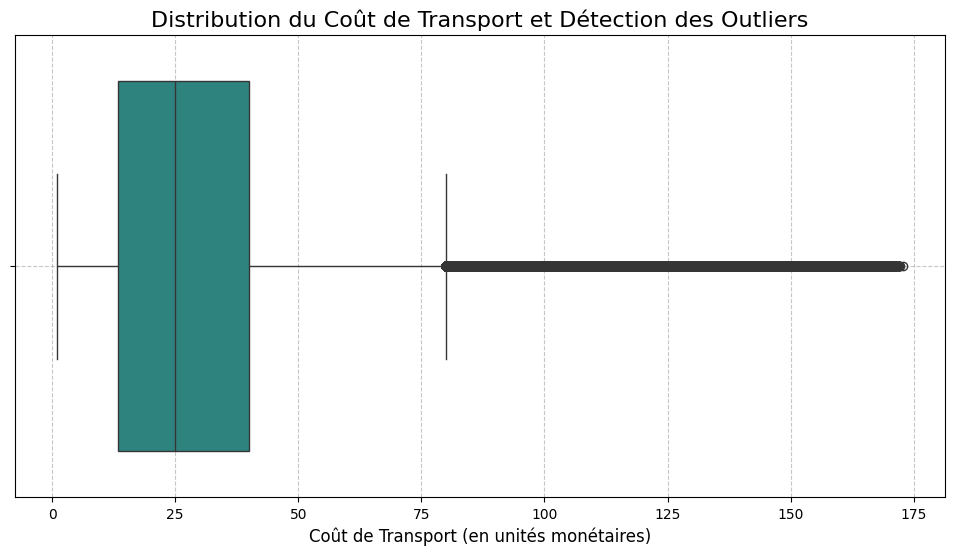

In [25]:
### Visualisation des Outliers sur Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x=lv['Cout_transport'], palette='viridis')
plt.title('Distribution du Coût de Transport et Détection des Outliers', fontsize=16)
plt.xlabel('Coût de Transport (en unités monétaires)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Interprétation du Boxplot du Coût de Transport

Ce boxplot visualise la distribution des coûts de transport et met en évidence les **outliers** (valeurs aberrantes) :

*   **La boîte centrale** : Représente les 50% du milieu des données (l'intervalle interquartile ou IQR). Le bord gauche de la boîte est le 25ème percentile (Q1), et le bord droit est le 75ème percentile (Q3).
*   **La ligne verticale à l'intérieur de la boîte** : C'est la médiane (50ème percentile ou Q2), qui divise les données en deux moitiés égales.
*   **Les moustaches (whiskers)** : Elles s'étendent des bords de la boîte jusqu'aux valeurs les plus éloignées qui ne sont pas considérées comme des outliers. Leur longueur est généralement calculée comme Q1 - 1.5 * IQR et Q3 + 1.5 * IQR. Toutes les valeurs au-delà de ces moustaches sont des outliers.
*   **Les points individuels au-delà des moustaches** : Ce sont les **outliers**. Dans notre cas, il s'agit des livraisons dont le coût de transport est anormalement élevé, comme nous l'avons identifié avec la méthode IQR. La borne supérieure que nous avons calculée (environ 80.04) correspond à la limite de la moustache supérieure, et tous les points au-delà de celle-ci sont les outliers.

# 9. Performances comparatives des transporteus

#### Performance Comparative des Transporteurs: Nous allons approfondir l'analyse des transporteurs pour identifier les plus performants et les moins performants en termes combinés de délai, coût et satisfaction. Nous vérifierons si le taux de retard de chaque transporteur est directement lié à sa note de satisfaction moyenne et s'il existe une différence significative dans leurs Cout_par_Km.

Facteurs Détaillés du Coût de Transport: Nous analyserons comment les Catégorie_poids et Type_colis influencent spécifiquement le Cout_transport et le Cout_par_Km. L'objectif est de détecter s'il y a des Cout_par_Km anormalement élevés ou faibles pour certaines combinaisons Transporteur/Type_colis ou Catégorie_poids, afin d'optimiser les stratégies de tarification.

Analyse Géographique des Flux: Nous identifierons les paires Ville_depart/Ville_arrivee les plus fréquentes et celles qui présentent les coûts moyens les plus élevés, les délais moyens les plus longs ou les taux de retard les plus importants. Cela nous aidera à repérer les routes problématiques ou les opportunités d'optimisation logistique.


In [35]:
import pandas as pd
import numpy as np

# 1. Identifier les paires Ville_depart/Ville_arrivee les plus fréquentes
routes_frequentes = lv.groupby(['Ville_depart', 'Ville_arrivee']).size().nlargest(10).reset_index(name='Nombre_livraisons')
print("\n1. Top 10 des paires Ville_depart/Ville_arrivee les plus fréquentes:")
display(routes_frequentes)


1. Top 10 des paires Ville_depart/Ville_arrivee les plus fréquentes:


,Ville_depart,Ville_arrivee,Nombre_livraisons
0,Marseille,Bordeaux,6891
1,Lyon,Rouen,6822
2,Toulouse,Rouen,6821
3,Toulouse,Marseille,6819
4,Toulouse,Paris,6809
5,Lyon,Montpellier,6803
6,Strasbourg,Marseille,6796
7,Paris,Lyon,6795
8,Marseille,Rennes,6794
9,Lille,Dijon,6791


In [36]:
# 2. Identifier les paires Ville_depart/Ville_arrivee avec les coûts moyens les plus élevés
routes_couts_eleves = lv.groupby(['Ville_depart', 'Ville_arrivee'])['Cout_transport'].mean().nlargest(10).reset_index(name='Cout_moyen')
print("\n2. Top 10 des paires Ville_depart/Ville_arrivee avec les coûts moyens les plus élevés:")
display(routes_couts_eleves)


2. Top 10 des paires Ville_depart/Ville_arrivee avec les coûts moyens les plus élevés:


,Ville_depart,Ville_arrivee,Cout_moyen
0,Strasbourg,Montpellier,37.943180
1,Nice,Strasbourg,37.929297
2,Paris,Nantes,37.842024
3,Nice,Lille,37.732938
4,Bordeaux,Lille,37.728153
5,Paris,Rouen,37.702637
6,Lyon,Strasbourg,37.697208
7,Lille,Strasbourg,37.690472
8,Lille,Rennes,37.652483
9,Toulouse,Paris,37.583871


In [37]:
# 3. Identifier les paires Ville_depart/Ville_arrivee avec les délais moyens les plus longs
routes_delais_longs = lv.groupby(['Ville_depart', 'Ville_arrivee'])['Delai_livraison'].mean().nlargest(10).reset_index(name='Delai_moyen')
print("\n3. Top 10 des paires Ville_depart/Ville_arrivee avec les délais moyens les plus longs:")
display(routes_delais_longs)


3. Top 10 des paires Ville_depart/Ville_arrivee avec les délais moyens les plus longs:


,Ville_depart,Ville_arrivee,Delai_moyen
0,Rennes,Nantes,4.060380
1,Lille,Lille,4.052890
2,Lyon,Rouen,4.049252
3,Nice,Dijon,4.044384
4,Lille,Toulouse,4.042171
5,Toulouse,Marseille,4.038862
6,Nice,Montpellier,4.038739
7,Bordeaux,Rouen,4.037617
8,Lille,Dijon,4.032543
9,Lille,Strasbourg,4.031283


In [38]:
# 4. Identifier les paires Ville_depart/Ville_arrivee avec les taux de retard les plus importants

# Calculer le nombre total de livraisons par route
total_livraisons_par_route = lv.groupby(['Ville_depart', 'Ville_arrivee']).size().reset_index(name='Total_livraisons')

# Calculer le nombre de livraisons en retard par route
retards_par_route = lv[lv['Statut'] == 'Retard'].groupby(['Ville_depart', 'Ville_arrivee']).size().reset_index(name='Nombre_retards')

# Fusionner les deux DataFrames
analyse_routes = pd.merge(total_livraisons_par_route, retards_par_route, on=['Ville_depart', 'Ville_arrivee'], how='left').fillna(0)

# Calculer le taux de retard
analyse_routes['Taux_retard_pct'] = (analyse_routes['Nombre_retards'] / analyse_routes['Total_livraisons']) * 100

# Identifier les 10 routes avec le taux de retard le plus élevé (en s'assurant qu'il y a un nombre suffisant de livraisons pour la pertinence)
# Par exemple, nous pouvons filtrer les routes avec au moins 100 livraisons
routes_taux_retard_eleves = analyse_routes[analyse_routes['Total_livraisons'] >= 100].sort_values(by='Taux_retard_pct', ascending=False).head(10)

print("\n4. Top 10 des paires Ville_depart/Ville_arrivee avec les taux de retard les plus importants (pour les routes avec au moins 100 livraisons):")
display(routes_taux_retard_eleves)


4. Top 10 des paires Ville_depart/Ville_arrivee avec les taux de retard les plus importants (pour les routes avec au moins 100 livraisons):


,Ville_depart,Ville_arrivee,Total_livraisons,Nombre_retards,Taux_retard_pct
112,Rennes,Nantes,6691,1196,17.874757
134,Strasbourg,Toulouse,6651,1187,17.846940
140,Toulouse,Marseille,6819,1216,17.832527
29,Lille,Toulouse,6687,1187,17.750860
89,Nice,Toulouse,6630,1176,17.737557
72,Nantes,Strasbourg,6733,1194,17.733551
11,Bordeaux,Rouen,6646,1178,17.724947
18,Lille,Lille,6731,1193,17.723964
9,Bordeaux,Paris,6703,1188,17.723407
49,Marseille,Lyon,6694,1184,17.687481


Coût moyen et Coût par Km moyen par Catégorie de Poids:


/tmp/ipykernel_582/1880855836.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analyse_cout_par_categorie_poids = lv.groupby('Categorie_poids')[['Cout_transport', 'Cout_par_Km']].mean().reset_index()


,Categorie_poids,Cout_transport,Cout_par_Km
0,Leger,9.510888,0.028385
1,Moyen,34.448031,0.102504
2,Lourd,92.257865,0.275070


/tmp/ipykernel_582/1880855836.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Categorie_poids', y='Cout_par_Km', data=analyse_cout_par_categorie_poids, palette='magma')


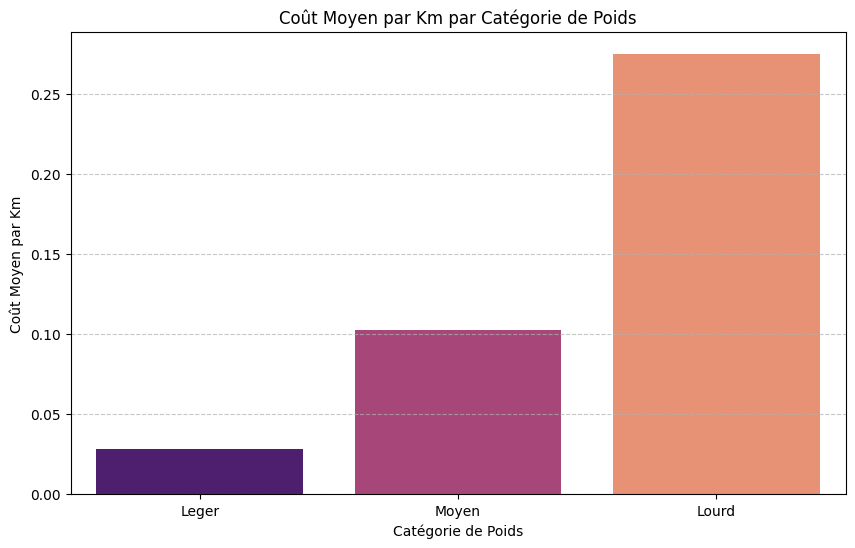

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

analyse_cout_par_categorie_poids = lv.groupby('Categorie_poids')[['Cout_transport', 'Cout_par_Km']].mean().reset_index()

print("Coût moyen et Coût par Km moyen par Catégorie de Poids:")
display(analyse_cout_par_categorie_poids)

# 2. Visualisation du Cout_par_Km moyen par Catégorie_poids
plt.figure(figsize=(10, 6))
sns.barplot(x='Categorie_poids', y='Cout_par_Km', data=analyse_cout_par_categorie_poids, palette='magma')
plt.title('Coût Moyen par Km par Catégorie de Poids')
plt.xlabel('Catégorie de Poids')
plt.ylabel('Coût Moyen par Km')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [1]:
import os
print(os.getcwd())

C:\Users\pc\Python\Exercise\Projet
